<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

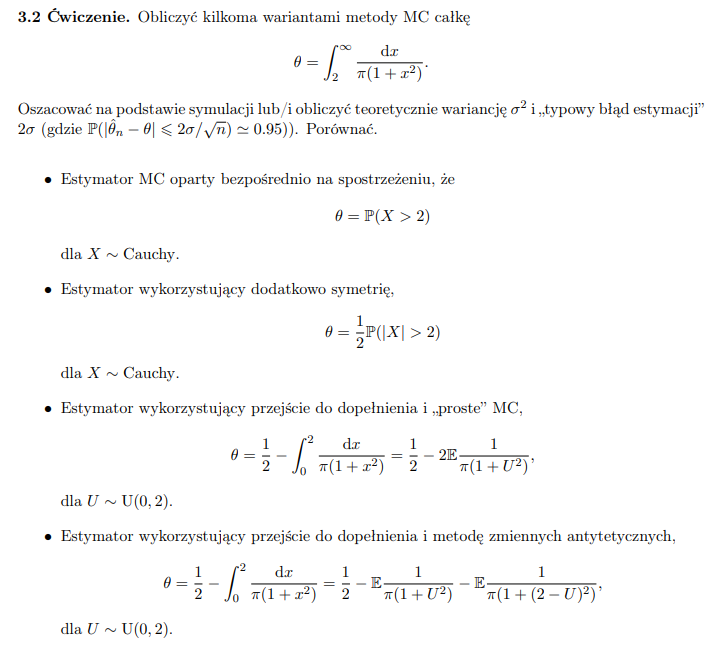

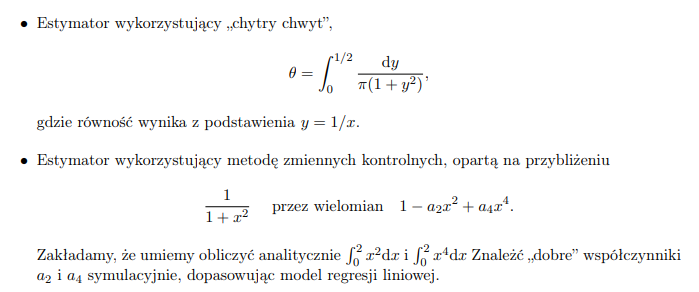

## Theoretical result
---
Firstly, let us compute the integral analytically:

$$\theta = \int_2^\infty \frac{dx}{\pi(1+x^2)} = \left[ \frac{1}{\pi} \arctan(x) \right]_2^\infty = \frac{1}{2} - \frac{\arctan(2)}{\pi} \approx 0.1475836$$

## Simulations
---

In [3]:
import numpy as np
import pandas as pd

In [4]:
# setup
N = 1_000_000
z_alpha = 2.0
results = {}
theta_theory = 0.5 - np.arctan(2) / np.pi

### 1. Direct method
----

We will use the observation that:

$$\theta = \mathbb{P}(X>2)$$

In [5]:
X1 = np.random.standard_cauchy(N)
Y1 = (X1 > 2).astype(float)
theta1 = np.mean(Y1)
var1 = np.var(Y1, ddof=1)
err1 = 2 * np.sqrt(var1 / N)
results["1. Direct method"] = (theta1, var1, err1)

### 2. Symmetry method
----

Now, we will use the estimator utilizing symmetry:

$$\theta = \frac{1}{2}\mathbb{P}(|X|>2)$$

In [6]:
X2 = np.random.standard_cauchy(N)
Y2 = 0.5 * (np.abs(X2) > 2).astype(float)
theta2 = np.mean(Y2)
var2 = np.var(Y2, ddof=1)
err2 = 2 * np.sqrt(var2 / N)
results["2. Symmetry method"] = (theta2, var2, err2)

### 3. Complement method
----

Instead of integrating the "tail" to infinity, we calculate the area under the curve on the interval $[2, \infty)$ by subtracting the area on $[0, 2]$ from the entire right half of the distribution:

$$\theta = \frac{1}{2} - \int_0^2 \frac{dx}{\pi(1+x^2)} = \frac{1}{2} - 2\mathbb{E}\left[\frac{1}{\pi(1+U^2)}\right]$$
for $U \sim \mathcal{U}(0, 2)$.

In [7]:
U = np.random.uniform(0, 2, N)
Y3_int = 2 / (np.pi * (1 + U**2))
Y3 = 0.5 - Y3_int
theta3 = np.mean(Y3)
var3 = np.var(Y3, ddof=1)
err3 = 2 * np.sqrt(var3 / N)
results["3. Complement method"] = (theta3, var3, err3)

### 4. Antithetic Variates
---
Now, extending the approach from the previous method, we may use the antithetic variables method:

$$\theta = \frac{1}{2} - \mathbb{E}\left[\frac{1}{\pi(1+U^2)}\right] - \mathbb{E}\left[\frac{1}{\pi(1+(2-U)^2)}\right]$$
for $U \sim \mathcal{U}(0, 2)$.

In [8]:
Y4_int = 1 / (np.pi * (1 + U**2)) + 1 / (np.pi * (1 + (2 - U)**2))
Y4 = 0.5 - Y4_int
theta4 = np.mean(Y4)
var4 = np.var(Y4, ddof=1)
err4 = 2 * np.sqrt(var4 / N)
results["4. Antithetic Variates"] = (theta4, var4, err4)

### 5. Clever trick
---
Applying the substitution $y = 1/x$ transforms the integral to:

$$\theta = \int_0^{1/2} \frac{dy}{\pi(1+y^2)} = \frac{1}{2}\mathbb{E}\left[\frac{1}{\pi(1+V^2)}\right]$$
for $V \sim \mathcal{U}(0, 1/2)$.

In [9]:
V = np.random.uniform(0, 0.5, N)
Y5 = 0.5 / (np.pi * (1 + V**2))
theta5 = np.mean(Y5)
var5 = np.var(Y5, ddof=1)
err5 = 2 * np.sqrt(var5 / N)
results["5. Clever trick"] = (theta5, var5, err5)

### 6. Regression
---
We use the analytical similarity of the integrand to its Taylor series expansion. Using linear regression, we fit the optimal coefficients $a_2$ and $a_4$.

$$\frac{1}{1+x^2} \approx 1 - a_2 x^2 + a_4 x^4$$

In [12]:
# variables
X_sq = U**2
X_quad = U**4

# Searching for optimal parameters a2 and a4
# Y = c0 + c1*X_sq + c2*X_quad
A = np.vstack([X_sq, X_quad]).T
A_centered = A - np.mean(A, axis=0)
Y3_centered = Y3_int - np.mean(Y3_int)

# OLS: calculating a2 and a4
coeffs = np.linalg.lstsq(A_centered, Y3_centered, rcond=None)[0]
a2, a4 = coeffs

# Teoretical expected values U ~ U(0, 2)
# E[U^2] = 1/2 * int_0^2 x^2 dx = 4/3
# E[U^4] = 1/2 * int_0^2 x^4 dx = 16/5
mu_X_sq = 4/3
mu_X_quad = 16/5

# Estimator with controlled variables: Y - c*(X - E[X])
Y6_int = Y3_int - a2 * (X_sq - mu_X_sq) - a4 * (X_quad - mu_X_quad)
Y6 = 0.5 - Y6_int
theta6 = np.mean(Y6)
var6 = np.var(Y6, ddof=1)
err6 = 2 * np.sqrt(var6 / N)
results["6. Regression"] = (theta6, var6, err6)

### Results
---

In [13]:
# code for rendering table with results
methods = ["0. Theoretical Value"]
thetas = [f"{theta_theory:.8f}"]
variances = ["-"]
errors = ["-"]

for name, (theta, var, err) in results.items():
    methods.append(name)
    thetas.append(f"{theta:.8f}")
    variances.append(f"{var:.8e}")
    errors.append(f"{err:.8e}")

df_results = pd.DataFrame({
    "Method": methods,
    "Estimator (θ)": thetas,
    "Variance (σ²)": variances,
    "Error 2σ/√N": errors
})

styled_df = df_results.style.set_properties(**{
                    'text-align': 'center',
                    'white-space': 'nowrap'
                }) \
                .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
                .hide(axis="index")

styled_df

Method,Estimator (θ),Variance (σ²),Error 2σ/√N
0. Theoretical Value,0.14758362,-,-
1. Direct method,0.14773700,1.25910905e-01,7.09678532e-04
2. Symmetry method,0.14747800,5.19892915e-02,4.56023208e-04
3. Complement method,0.14744928,2.85110392e-02,3.37704244e-04
4. Antithetic Variates,0.14758974,5.83633112e-04,4.83169996e-05
5. Clever trick,0.14757699,9.56557680e-05,1.95607534e-05
6. Regression,0.14757197,6.28397443e-04,5.01357135e-05


####